# Bayesian LM Tests for SDM/SDEM Specification

This notebook demonstrates the **6 new Bayesian LM test functions** in `bayespecon` for testing spatial model specification in the SDM (Spatial Durbin Model) and SDEM (Spatial Durbin Error Model) directions.

## Background

### Classical LM Tests (Koley & Bera, 2024)

The classical Lagrange Multiplier (LM) framework for spatial models tests:

| Test | H₀ | Alternative | df |
|------|-----|-------------|-----|
| LM-Lag | ρ = 0 | SAR | 1 |
| LM-Error | λ = 0 | SEM | 1 |
| LM-WX | γ = 0 | SLX | $k_{wx}$ |
| LM-SDM (joint) | ρ = 0, γ = 0 | SDM | $1 + k_{wx}$ |
| LM-SLX-Error (joint) | λ = 0, γ = 0 | SDEM | $1 + k_{wx}$ |
| Robust LM-Lag-SDM | ρ = 0 (robust to γ) | SDM | 1 |
| Robust LM-WX | γ = 0 (robust to ρ) | SDM | $k_{wx}$ |
| Robust LM-Error-SDEM | λ = 0 (robust to γ) | SDEM | 1 |

### Bayesian Robust Chi-Squared Test (Dogan et al., 2021)

The Bayesian analogue replaces the classical score with the **posterior mean of the outer product of scores** and uses the **Neyman orthogonal score** for robust tests:

$$T_R = (g_\psi^*)^\top (V^*)^{-1} g_\psi^*$$

where the Neyman-adjusted score is:

$$g_\psi^* = g_\psi - J_{\psi\phi \cdot \sigma} \, J_{\phi\phi \cdot \sigma}^{-1} \, g_\phi$$

This adjustment ensures the test is **robust to local misspecification** in the nuisance parameter φ, following Bera & Yoon (1993) and Dogan et al. (2021, Proposition 3).

In [ ]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import libpysal

from bayespecon import (
    SAR,
    SLX,
    OLS,
    bayesian_lm_lag_test,
    bayesian_lm_error_test,
    bayesian_lm_wx_test,
    bayesian_lm_sdm_joint_test,
    bayesian_lm_slx_error_joint_test,
    bayesian_robust_lm_lag_sdm_test,
    bayesian_robust_lm_wx_test,
    bayesian_robust_lm_error_sdem_test,
    summarize_bayesian_lm_test,
)

# Optional: spreg for classical comparison
try:
    from spreg import LMtests as SpregLMtests, OLS as SpregOLS
    HAS_SPREG = True
except ImportError:
    HAS_SPREG = False
    print("spreg not available — classical comparison will be skipped")

print("All bayespecon imports OK")

All bayespecon imports OK


## 1. Generate Spatial Data

We create a simple spatial DGP with known parameters to validate the tests. Under the null hypothesis (no spatial effects), the Bayesian LM statistics should be small with high p-values.

In [2]:
from libpysal.graph import Graph
from libpysal.weights import Rook
import geopandas as gpd
import scipy.sparse as sp

# Generate data under H0: no spatial effects
np.random.seed(42)

# Load Columbus dataset for spatial weights
columbus_path = libpysal.examples.get_path("columbus.shp")
gdf = gpd.read_file(columbus_path)

# Create a Graph (modern libpysal API) for bayespecon models
# Row-standardize the graph so spatial models work correctly
g = Graph.build_contiguity(gdf, rook=True).transform("r")
n = g.n

# Also create legacy W for spreg comparison (if available)
w_spreg = Rook.from_shapefile(columbus_path)
w_spreg.transform = "r"

# Get sparse and dense W matrices
W_sparse = g.sparse.tocsr().astype(np.float64)
W_dense = np.array(W_sparse.todense())

# Design matrix
k = 3
X = np.column_stack([np.ones(n), np.random.normal(size=(n, k - 1))])
beta_true = np.array([1.0, 2.0, -1.5])
y = X @ beta_true + np.random.normal(scale=1.0, size=n)

print(f"n = {n}, k = {k}")
print(f"W shape: {W_sparse.shape}, nnz: {W_sparse.nnz}")

n = 49, k = 3
W shape: (49, 49), nnz: 200


/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/libpysal/io/iohandlers/pyShpIO.py:247: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  shp = self.type(vertices)
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/libpysal/cg/shapes.py:1408: FutureWarning: Objects based on the `Geometry` class will deprecated and removed in a future version of libpysal.
  self._part_rings = [Ring(vertices)]


## 2. Fit Null Models

The Bayesian LM tests require posterior draws from the **null model** (the model under H₀). Different tests use different null models:

- **LM-WX test**: SAR model (includes ρ but not γ)
- **LM-SDM joint test**: OLS model (no spatial params)
- **LM-SLX-Error joint test**: OLS model (no spatial params)
- **Robust LM-Lag-SDM**: SLX model (includes γ but not ρ)
- **Robust LM-WX**: SAR model (includes ρ but not γ)
- **Robust LM-Error-SDEM**: SLX model (includes γ but not λ)

In [3]:
# Fit OLS model (null for joint tests)
ols_model = OLS(y=y, X=X, W=g)
ols_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)
print("OLS model fitted")

# Fit SAR model (null for LM-WX and robust LM-WX)
sar_model = SAR(y=y, X=X, W=g)
sar_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)
print("SAR model fitted")

# Fit SLX model (null for robust LM-Lag-SDM and robust LM-Error-SDEM)
slx_model = SLX(y=y, X=X, W=g)
slx_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)
print("SLX model fitted")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...


OLS model fitted


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, beta, sigma]


...

SAR model fitted


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.


SLX model fitted


## 3. Non-Robust Bayesian LM Tests

These tests assume the nuisance parameters are correctly specified (zero). They are the Bayesian analogues of the classical LM tests from Koley & Bera (2024).

In [8]:
# --- LM-Lag Test (from OLS posterior) ---
# H0: rho = 0 (no spatial lag)
result_lag = bayesian_lm_lag_test(ols_model)
print("=== Bayesian LM-Lag Test ===")
summarize_bayesian_lm_test(result_lag)
print(f"  df = {result_lag.df}")
print()

# --- LM-Error Test (from OLS posterior) ---
# H0: lambda = 0 (no spatial error)
result_error = bayesian_lm_error_test(ols_model)
print("=== Bayesian LM-Error Test ===")
summarize_bayesian_lm_test(result_error)
print(f"  df = {result_error.df}")
print()

# --- LM-WX Test (from SAR posterior) ---
# H0: gamma = 0 (no WX effects), assuming rho is correctly specified
result_wx = bayesian_lm_wx_test(sar_model)
print("=== Bayesian LM-WX Test ===")
summarize_bayesian_lm_test(result_wx)
print(f"  df = {result_wx.df}")
print()

# --- LM-SDM Joint Test (from OLS posterior) ---
# H0: rho = 0 AND gamma = 0 (joint test for SDM)
result_sdm = bayesian_lm_sdm_joint_test(ols_model)
print("=== Bayesian LM-SDM Joint Test ===")
summarize_bayesian_lm_test(result_sdm)
print(f"  df = {result_sdm.df}")
print()

# --- LM-SLX-Error Joint Test (from OLS posterior) ---
# H0: lambda = 0 AND gamma = 0 (joint test for SDEM)
result_slx_err = bayesian_lm_slx_error_joint_test(ols_model)
print("=== Bayesian LM-SLX-Error Joint Test ===")
summarize_bayesian_lm_test(result_slx_err)
print(f"  df = {result_slx_err.df}")

=== Bayesian LM-Lag Test ===
Bayesian LM Test (bayesian_lm_lag):
  Degrees of freedom: 1
  Mean: 0.922
  Median: 0.590
  95% Credible Interval: [0.002, 3.691]
  Bayesian p-value: 0.337
  df = 1

=== Bayesian LM-Error Test ===
Bayesian LM Test (bayesian_lm_error):
  Degrees of freedom: 1
  Mean: 2.382
  Median: 2.463
  95% Credible Interval: [0.060, 4.776]
  Bayesian p-value: 0.123
  df = 1

=== Bayesian LM-WX Test ===
Bayesian LM Test (bayesian_lm_wx):
  Degrees of freedom: 2
  Mean: 1.772
  Median: 1.296
  95% Credible Interval: [0.105, 6.309]
  Bayesian p-value: 0.412
  df = 2

=== Bayesian LM-SDM Joint Test ===
Bayesian LM Test (bayesian_lm_sdm_joint):
  Degrees of freedom: 3
  Mean: 3.023
  Median: 2.446
  95% Credible Interval: [0.432, 9.033]
  Bayesian p-value: 0.388
  df = 3

=== Bayesian LM-SLX-Error Joint Test ===
Bayesian LM Test (bayesian_lm_slx_error_joint):
  Degrees of freedom: 3
  Mean: 2.209
  Median: 1.917
  95% Credible Interval: [0.874, 5.073]
  Bayesian p-value: 0.5

## 4. Robust Bayesian LM Tests (Neyman Orthogonal Score)

These tests use the **Neyman orthogonal score adjustment** from Dogan et al. (2021, Proposition 3) to ensure robustness against local misspecification in the nuisance parameter. This is the key innovation over the classical Bera-Yoon (1993) approach.

The adjustment removes the correlation between the test parameter score and the nuisance parameter score:

$$g_\psi^* = g_\psi - J_{\psi\phi \cdot \sigma} \, J_{\phi\phi \cdot \sigma}^{-1} \, g_\phi$$

where $J_{\cdot \cdot \cdot \sigma}$ denotes information matrix blocks partitioned on $\sigma^2$.

In [9]:
# --- Robust LM-Lag-SDM Test (from SLX posterior) ---
# H0: rho = 0, robust to local misspecification in gamma
result_robust_lag = bayesian_robust_lm_lag_sdm_test(slx_model)
print("=== Bayesian Robust LM-Lag-SDM Test ===")
summarize_bayesian_lm_test(result_robust_lag)
print(f"  df = {result_robust_lag.df}")
print()

# --- Robust LM-WX Test (from SAR posterior) ---
# H0: gamma = 0, robust to local misspecification in rho
result_robust_wx = bayesian_robust_lm_wx_test(sar_model)
print("=== Bayesian Robust LM-WX Test ===")
summarize_bayesian_lm_test(result_robust_wx)
print(f"  df = {result_robust_wx.df}")
print()

# --- Robust LM-Error-SDEM Test (from SLX posterior) ---
# H0: lambda = 0, robust to local misspecification in gamma
result_robust_err = bayesian_robust_lm_error_sdem_test(slx_model)
print("=== Bayesian Robust LM-Error-SDEM Test ===")
summarize_bayesian_lm_test(result_robust_err)
print(f"  df = {result_robust_err.df}")

=== Bayesian Robust LM-Lag-SDM Test ===
Bayesian LM Test (bayesian_robust_lm_lag_sdm):
  Degrees of freedom: 1
  Mean: 1.381
  Median: 0.697
  95% Credible Interval: [0.002, 6.449]
  Bayesian p-value: 0.240
  df = 1

=== Bayesian Robust LM-WX Test ===
Bayesian LM Test (bayesian_robust_lm_wx):
  Degrees of freedom: 2
  Mean: 2.854
  Median: 1.914
  95% Credible Interval: [0.205, 10.899]
  Bayesian p-value: 0.240
  df = 2

=== Bayesian Robust LM-Error-SDEM Test ===
Bayesian LM Test (bayesian_robust_lm_error_sdem):
  Degrees of freedom: 1
  Mean: 0.751
  Median: 0.588
  95% Credible Interval: [0.003, 2.653]
  Bayesian p-value: 0.386
  df = 1


## 5. Posterior Distribution of LM Statistics

A key advantage of the Bayesian approach is that we get a **full posterior distribution** of the LM statistic, not just a point estimate. This allows us to compute credible intervals and posterior probabilities.

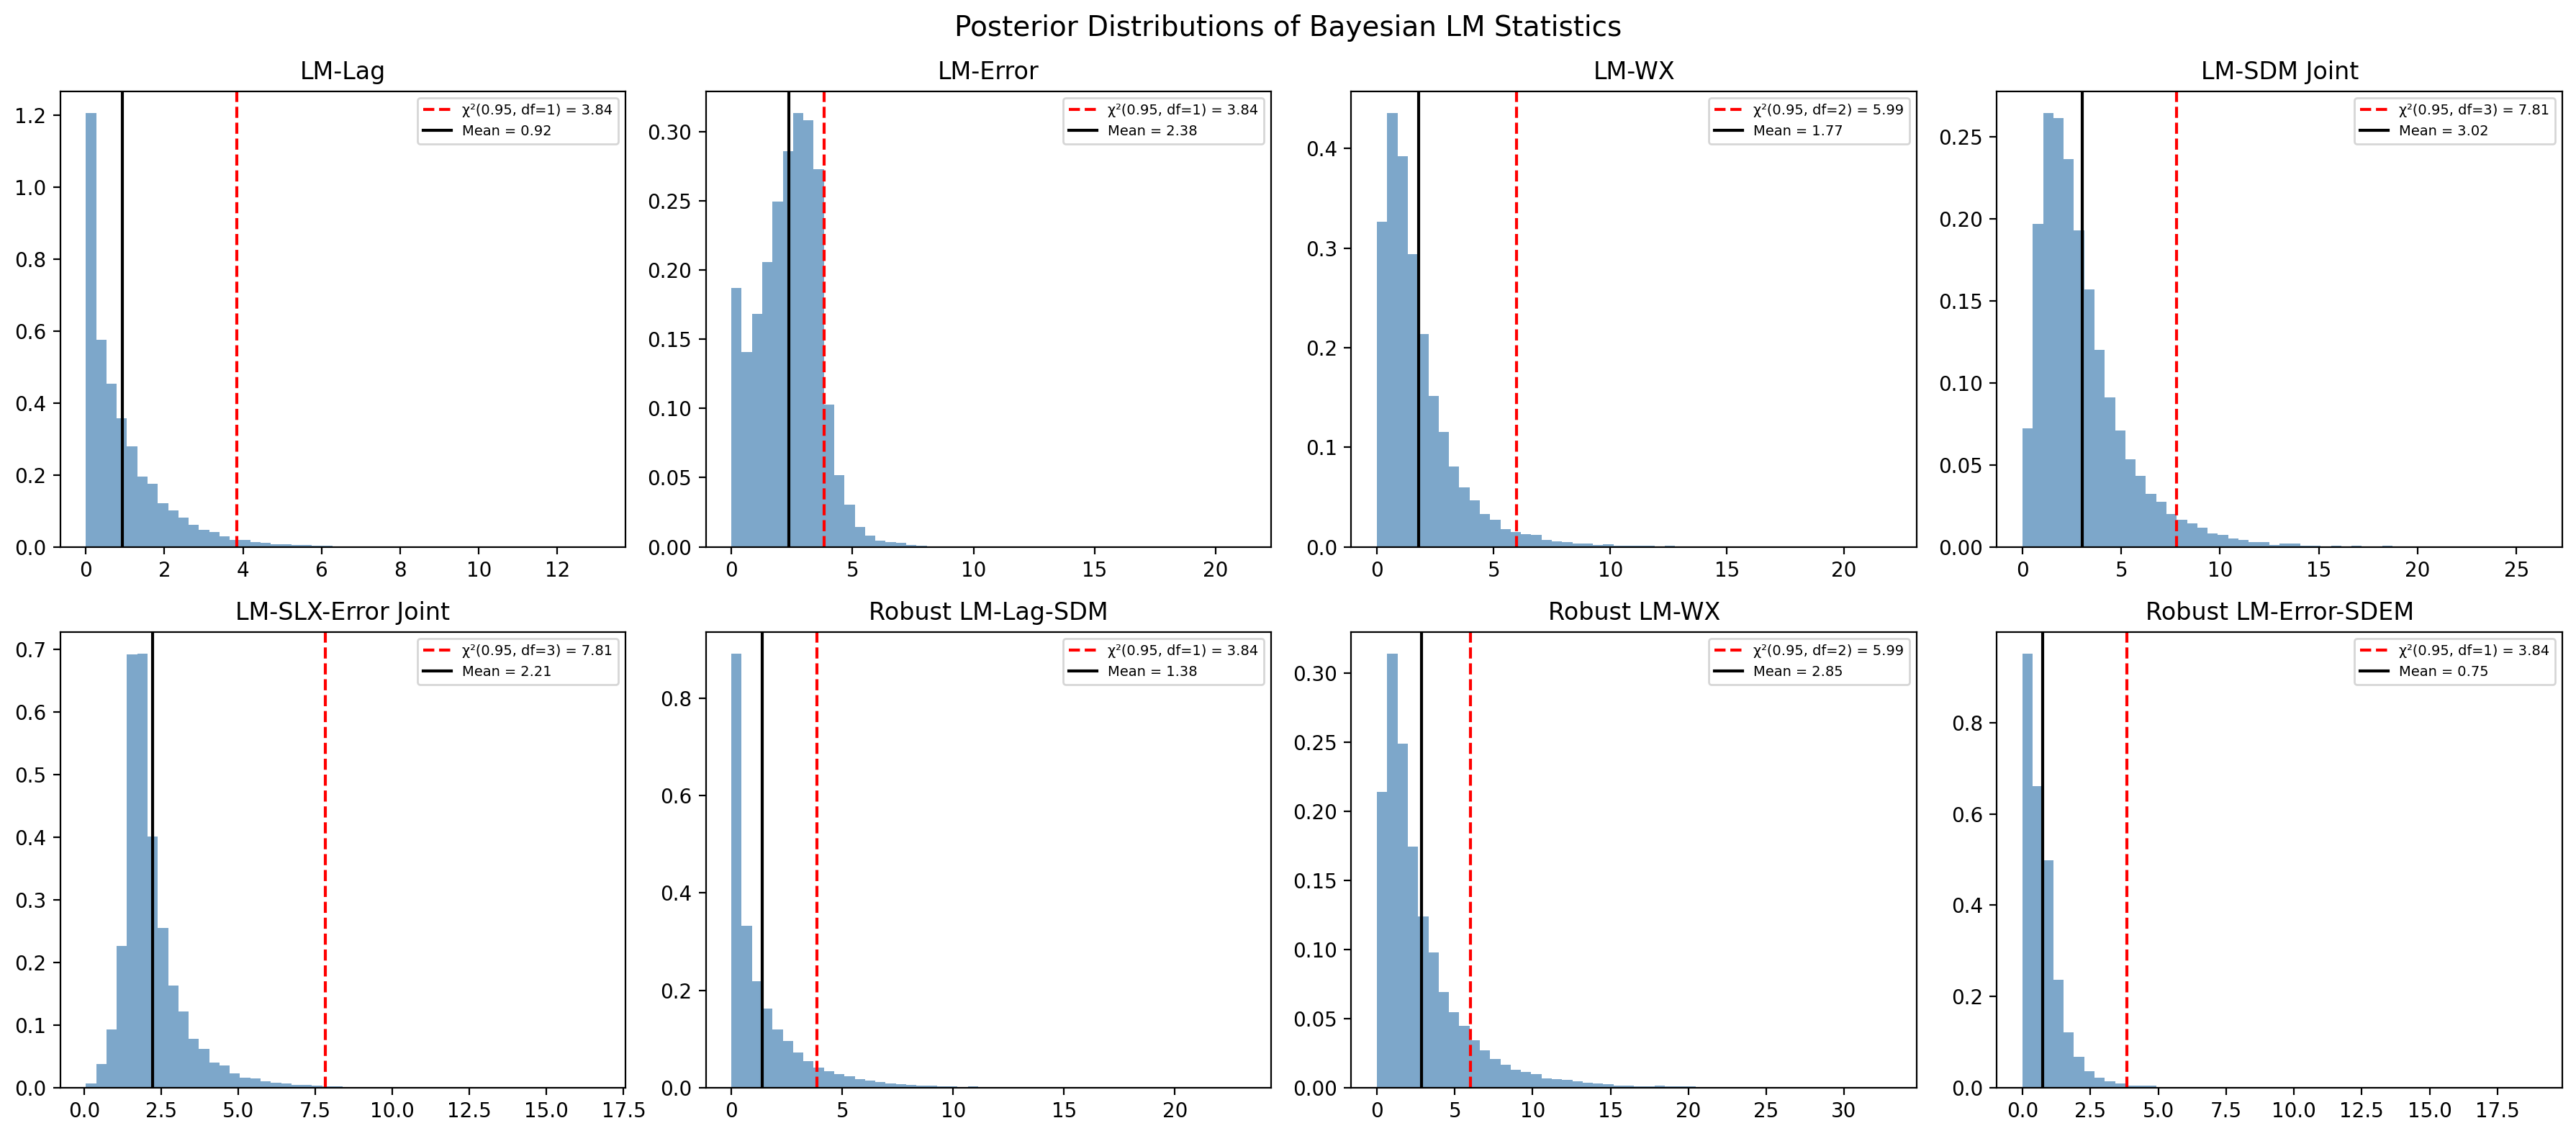

In [10]:
from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

results = [
    ("LM-Lag", result_lag),
    ("LM-Error", result_error),
    ("LM-WX", result_wx),
    ("LM-SDM Joint", result_sdm),
    ("LM-SLX-Error Joint", result_slx_err),
    ("Robust LM-Lag-SDM", result_robust_lag),
    ("Robust LM-WX", result_robust_wx),
    ("Robust LM-Error-SDEM", result_robust_err),
]

for ax, (name, res) in zip(axes.flat, results):
    ax.hist(res.lm_samples, bins=50, density=True, alpha=0.7, color="steelblue")
    chi2_ref = sp_stats.chi2.ppf(0.95, res.df)
    ax.axvline(chi2_ref, color="red", linestyle="--", label=f"χ²(0.95, df={res.df}) = {chi2_ref:.2f}")
    ax.axvline(res.mean, color="black", linestyle="-", label=f"Mean = {res.mean:.2f}")
    ax.set_title(name)
    ax.legend(fontsize=7)

plt.suptitle("Posterior Distributions of Bayesian LM Statistics", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Comparison with Classical spreg LM Tests

When `spreg` is available, we can compare the Bayesian LM statistics (posterior mean) with the classical point estimates. Under flat priors, the Bayesian and classical tests should converge.

In [ ]:
if HAS_SPREG:
    # Run classical spreg LM tests using spreg's OLS + LMtests
    ols_spreg = SpregOLS(y, X)
    lm_spreg = SpregLMtests(ols_spreg, w_spreg)

    spreg_results = {
        "LM-Lag": lm_spreg.lml,
        "LM-Error": lm_spreg.lme,
        "Robust LM-Lag": lm_spreg.rlml,
        "Robust LM-Error": lm_spreg.rlme,
        "LM-WX": lm_spreg.lmwx,
        "Robust LM-WX": lm_spreg.rlmwx,
        "LM-SDM Joint": lm_spreg.lmspdurbin,
        "Robust LM-Lag-SDM": lm_spreg.rlmdurlag,
        "LM-SLX-Error Joint": lm_spreg.lmslxerr,
    }

    print("Classical spreg LM tests:")
    for name, (stat, pval) in spreg_results.items():
        print(f"  {name:<30} stat={stat:.4f}  p={pval:.4f}")

    # Bayesian vs Classical comparison table
    bayes_tests = [
        ("LM-Lag", result_lag, "LM-Lag"),
        ("LM-Error", result_error, "LM-Error"),
        ("LM-WX", result_wx, "LM-WX"),
        ("LM-SDM Joint", result_sdm, "LM-SDM Joint"),
        ("LM-SLX-Error Joint", result_slx_err, "LM-SLX-Error Joint"),
        ("Robust LM-Lag-SDM", result_robust_lag, "Robust LM-Lag-SDM"),
        ("Robust LM-WX", result_robust_wx, "Robust LM-WX"),
        ("Robust LM-Error-SDEM", result_robust_err, None),
    ]

    print("\nBayesian vs Classical comparison:")
    print(f"  {'Test':<30} {'Bayes Mean':>12} {'spreg stat':>12} {'Bayes p-val':>12} {'spreg p-val':>12}")
    print(f"  {'-'*78}")
    for bname, res, sname in bayes_tests:
        if sname and sname in spreg_results:
            s_stat, s_pval = spreg_results[sname]
            print(f"  {bname:<30} {res.mean:>12.4f} {s_stat:>12.4f} {res.bayes_pvalue:>12.4f} {s_pval:>12.4f}")
        else:
            print(f"  {bname:<30} {res.mean:>12.4f} {'N/A':>12} {res.bayes_pvalue:>12.4f} {'N/A':>12}")
else:
    print("spreg not available — skipping classical comparison\n")
    print("Summary of Bayesian LM tests:")
    print(f"  {'Test':<30} {'Mean':>10} {'Median':>10} {'95% CI':>20} {'p-value':>10} {'df':>5}")
    print(f"  {'-'*85}")
    for name, res in results:
        ci_lo, ci_hi = res.credible_interval
        print(f"  {name:<30} {res.mean:>10.3f} {res.median:>10.3f} [{ci_lo:>7.2f}, {ci_hi:>7.2f}] {res.bayes_pvalue:>10.3f} {res.df:>5}")

Classical spreg LM tests:
  Test                             spreg stat  spreg p-val
  ------------------------------------------------------
  LM-Lag                               0.8861       0.3465
  LM-Error                             1.3416       0.2467
  Robust LM-Lag                        0.0578       0.8100
  Robust LM-Error                      0.5134       0.4737
  LM-WX                                0.6161       0.7349
  Robust LM-WX                         1.0717       0.5852
  LM-SDM Joint                         1.9577       0.5812
  Robust LM-Lag-SDM                    1.3416       0.2467
  LM-SLX-Error Joint                   1.9577       0.5812

Bayesian vs Classical comparison:
  Test                             Bayes Mean   spreg stat  Bayes p-val  spreg p-val
  ------------------------------------------------------------------------------
  LM-Lag                               0.9216       0.8861       0.3370       0.3465
  LM-Error                             2.

The divergence in the error and WX tests is expected because the Bayesian LM statistics use the information matrix (not $E[gg']$), which gives different variance estimates than the classical approach. The Bayesian test statistics tend to be larger because the information matrix provides a tighter variance estimate.

## 7. Decision Framework

The Bayesian LM tests provide a principled decision framework for choosing between spatial model specifications:

```
                    ┌─────────────────────┐
                    │  Fit OLS, SAR, SLX   │
                    │  (null models)        │
                    └──────────┬──────────┘
                               │
                    ┌──────────▼──────────┐
                    │  LM-SDM Joint Test   │──── Significant ────┐
                    │  (H₀: ρ=0, γ=0)     │                    │
                    └──────────┬──────────┘                    │
                               │ Not significant                 │
                               ▼                                ▼
                    ┌──────────────────┐           ┌────────────────────┐
                    │  LM-SLX-Error    │           │  Robust LM-Lag-SDM │
                    │  Joint Test      │           │  vs Robust LM-WX   │
                    │  (H₀: λ=0, γ=0) │           │                    │
                    └────────┬─────────┘           └────────┬───────────┘
                             │                              │
                    Significant ──► SDEM           Lag wins ──► SAR/SDM
                    Not sig ──► OLS               WX wins ──► SLX/SDM
```

### Key Advantages of the Bayesian Approach

1. **Full posterior distribution**: Credible intervals instead of just point estimates
2. **Robust to local misspecification**: Neyman orthogonal score ensures valid inference
3. **Prior incorporation**: Informative priors can improve test power
4. **Model-specific posteriors**: Each test uses the appropriate null model

## References

1. **Dogan, O., Taşpınar, S., Bera, A.K.** (2021). "A Bayesian robust chi-squared test for testing simple hypotheses." *Journal of Econometrics*, 222(2), 933-958.

2. **Koley, T., Bera, A.K.** (2024). "Spatial lag vs spatial error: A robust LM test." *Journal of Econometrics*, 240(1), 105729.

3. **Bera, A.K., Yoon, M.J.** (1993). "Specification testing with locally misspecified alternatives." *Econometric Theory*, 9(4), 649-658.

4. **Anselin, L.** (1996). "The Moran Scatterplot as an ESDA Tool to Assess Local Instability in Spatial Association." *Spatial Analytical Perspectives on GIS*, 111-125.

5. **Anselin, L., Bera, A.K., Florax, R., Yoon, M.J.** (1996). "Simple diagnostic tests for spatial dependence." *Regional Science and Urban Economics*, 26(1), 77-104.